In [2]:
import os
import sys


CURRENT_DIR = os.getcwd()
FOLDERS = CURRENT_DIR.split(os.sep)
TESIS_FOLDER_INDEX = FOLDERS.index('S-noise-gradient')
CURRENT_DIR = os.sep.join(FOLDERS[:TESIS_FOLDER_INDEX+1])
LIBS_PATH = os.path.join(CURRENT_DIR, 'src', 'libs')
assert os.path.exists(LIBS_PATH)
sys.path.append(CURRENT_DIR)
sys.path.append(LIBS_PATH)


# Import external and local libraries
# __________________________________________________________________________________________________
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import json
from typing import List

# Locals
from utils import *
from dataset import DFDataset, TensorDataset
from models import *
import config as cfg
from dlnr import DLNoiseReduction


# Global / Path variables
# __________________________________________________________________________________________________
DATA_PATH = os.path.join(CURRENT_DIR, 'data', 'try_ts')
CHECKPOINT_PATH = os.path.join(CURRENT_DIR, 'checkpoints')
CONFIG_PATH = os.path.join(CURRENT_DIR, 'config')


# Make sure that the GPU is being used
# __________________________________________________________________________________________________
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert device.type == "cuda"

In [3]:
df = pd.read_parquet(os.path.join(DATA_PATH, 'gas_sensor_array_temperature_modulation', '20160930_203718.parquet'))
df

,Time (s),CO (ppm),Humidity (%r.h.),Temperature (C),Flow rate (mL/min),Heater voltage (V),R1 (MOhm),R2 (MOhm),R3 (MOhm),R4 (MOhm),R5 (MOhm),R6 (MOhm),R7 (MOhm),R8 (MOhm),R9 (MOhm),R10 (MOhm),R11 (MOhm),R12 (MOhm),R13 (MOhm),R14 (MOhm)
0,0.000,0.0,49.7534,23.7184,233.2737,0.8993,0.2231,0.6365,1.1493,0.8483,1.2534,1.4449,1.9906,1.3303,1.4480,1.9148,3.4651,5.2144,6.5806,8.6385
1,0.309,0.0,55.8400,26.6200,241.6323,0.2112,2.1314,5.3552,9.7569,6.3188,9.4472,10.5769,13.6317,21.9829,16.1902,24.2780,31.1014,34.7193,31.7505,41.9167
2,0.618,0.0,55.8400,26.6200,241.3888,0.2070,10.5318,22.5612,37.2635,17.7848,33.0704,36.3160,42.5746,49.7495,31.7533,57.7289,53.6275,56.9212,47.8255,62.9436
3,0.926,0.0,55.8400,26.6200,241.1461,0.2042,29.5749,49.5111,65.6318,26.1447,58.3847,67.5130,68.0064,59.2824,36.7821,66.0832,66.8349,66.9695,50.3730,64.8363
4,1.234,0.0,55.8400,26.6200,240.9121,0.2030,49.5111,67.0368,77.8317,27.9625,71.7732,79.9474,79.8631,62.5385,39.6271,68.1441,62.0947,49.4614,52.8453,66.8445
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295714,90908.545,0.0,62.3000,26.5800,0.0000,0.2000,5.5429,2.5713,10.3815,18.5796,36.4589,34.4549,38.3745,57.5888,45.7953,56.6351,56.4058,50.6129,43.0232,65.2822
295715,90908.853,0.0,62.3000,26.5800,0.0000,0.2000,4.5527,2.1454,8.5494,18.0592,36.6290,34.0052,37.6964,51.9752,45.0239,58.9374,61.6173,50.9361,43.4604,63.8761
295716,90909.162,0.0,62.3000,26.5800,0.0000,0.2000,3.7374,1.8492,7.1062,18.0087,36.0127,32.5056,37.1882,54.4724,45.0239,59.7462,57.1452,51.8182,42.5944,64.3090
295717,90909.469,0.0,62.3000,26.5800,0.0000,0.2000,3.1197,1.6190,5.9138,17.6950,37.5930,30.5253,35.9328,51.9752,45.5201,57.7289,60.3791,50.3466,42.4022,62.0375


In [4]:
df.set_index('Time (s)', inplace=True)
df

,CO (ppm),Humidity (%r.h.),Temperature (C),Flow rate (mL/min),Heater voltage (V),R1 (MOhm),R2 (MOhm),R3 (MOhm),R4 (MOhm),R5 (MOhm),R6 (MOhm),R7 (MOhm),R8 (MOhm),R9 (MOhm),R10 (MOhm),R11 (MOhm),R12 (MOhm),R13 (MOhm),R14 (MOhm)
Time (s),,,,,,,,,,,,,,,,,,,
0.000,0.0,49.7534,23.7184,233.2737,0.8993,0.2231,0.6365,1.1493,0.8483,1.2534,1.4449,1.9906,1.3303,1.4480,1.9148,3.4651,5.2144,6.5806,8.6385
0.309,0.0,55.8400,26.6200,241.6323,0.2112,2.1314,5.3552,9.7569,6.3188,9.4472,10.5769,13.6317,21.9829,16.1902,24.2780,31.1014,34.7193,31.7505,41.9167
0.618,0.0,55.8400,26.6200,241.3888,0.2070,10.5318,22.5612,37.2635,17.7848,33.0704,36.3160,42.5746,49.7495,31.7533,57.7289,53.6275,56.9212,47.8255,62.9436
0.926,0.0,55.8400,26.6200,241.1461,0.2042,29.5749,49.5111,65.6318,26.1447,58.3847,67.5130,68.0064,59.2824,36.7821,66.0832,66.8349,66.9695,50.3730,64.8363
1.234,0.0,55.8400,26.6200,240.9121,0.2030,49.5111,67.0368,77.8317,27.9625,71.7732,79.9474,79.8631,62.5385,39.6271,68.1441,62.0947,49.4614,52.8453,66.8445
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90908.545,0.0,62.3000,26.5800,0.0000,0.2000,5.5429,2.5713,10.3815,18.5796,36.4589,34.4549,38.3745,57.5888,45.7953,56.6351,56.4058,50.6129,43.0232,65.2822
90908.853,0.0,62.3000,26.5800,0.0000,0.2000,4.5527,2.1454,8.5494,18.0592,36.6290,34.0052,37.6964,51.9752,45.0239,58.9374,61.6173,50.9361,43.4604,63.8761
90909.162,0.0,62.3000,26.5800,0.0000,0.2000,3.7374,1.8492,7.1062,18.0087,36.0127,32.5056,37.1882,54.4724,45.0239,59.7462,57.1452,51.8182,42.5944,64.3090


In [5]:
nan_counts = df.isna().sum()
print((nan_counts/len(df))*100)

CO (ppm)              0.0
Humidity (%r.h.)      0.0
Temperature (C)       0.0
Flow rate (mL/min)    0.0
Heater voltage (V)    0.0
R1 (MOhm)             0.0
R2 (MOhm)             0.0
R3 (MOhm)             0.0
R4 (MOhm)             0.0
R5 (MOhm)             0.0
R6 (MOhm)             0.0
R7 (MOhm)             0.0
R8 (MOhm)             0.0
R9 (MOhm)             0.0
R10 (MOhm)            0.0
R11 (MOhm)            0.0
R12 (MOhm)            0.0
R13 (MOhm)            0.0
R14 (MOhm)            0.0
dtype: float64


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CO (ppm),295719.0,9.900786,6.429229,0.0000,4.4400,8.8900,15.5600,20.0000
Humidity (%r.h.),295719.0,45.966022,12.315889,17.5000,36.1700,46.6700,55.3300,71.9600
Temperature (C),295719.0,26.476381,0.211647,23.7184,26.3000,26.4600,26.6200,26.9400
Flow rate (mL/min),295719.0,239.942669,1.947498,0.0000,239.8958,239.9729,240.0462,275.1803
Heater voltage (V),295719.0,0.355293,0.288663,0.1990,0.2000,0.2000,0.2070,0.9010
R1 (MOhm),295719.0,14.962249,22.368187,0.0315,0.4048,1.6441,25.1595,113.4868
R2 (MOhm),295719.0,17.396103,26.648398,0.0560,0.4841,1.3561,28.8601,154.6290
R3 (MOhm),295719.0,22.233080,28.695365,0.0540,0.5863,4.0554,45.0994,182.3433
R4 (MOhm),295719.0,18.429670,15.210454,0.0402,2.0683,18.5796,29.2098,91.8226
R5 (MOhm),295719.0,31.054371,26.675759,0.0489,1.7852,32.3170,50.5620,124.1949


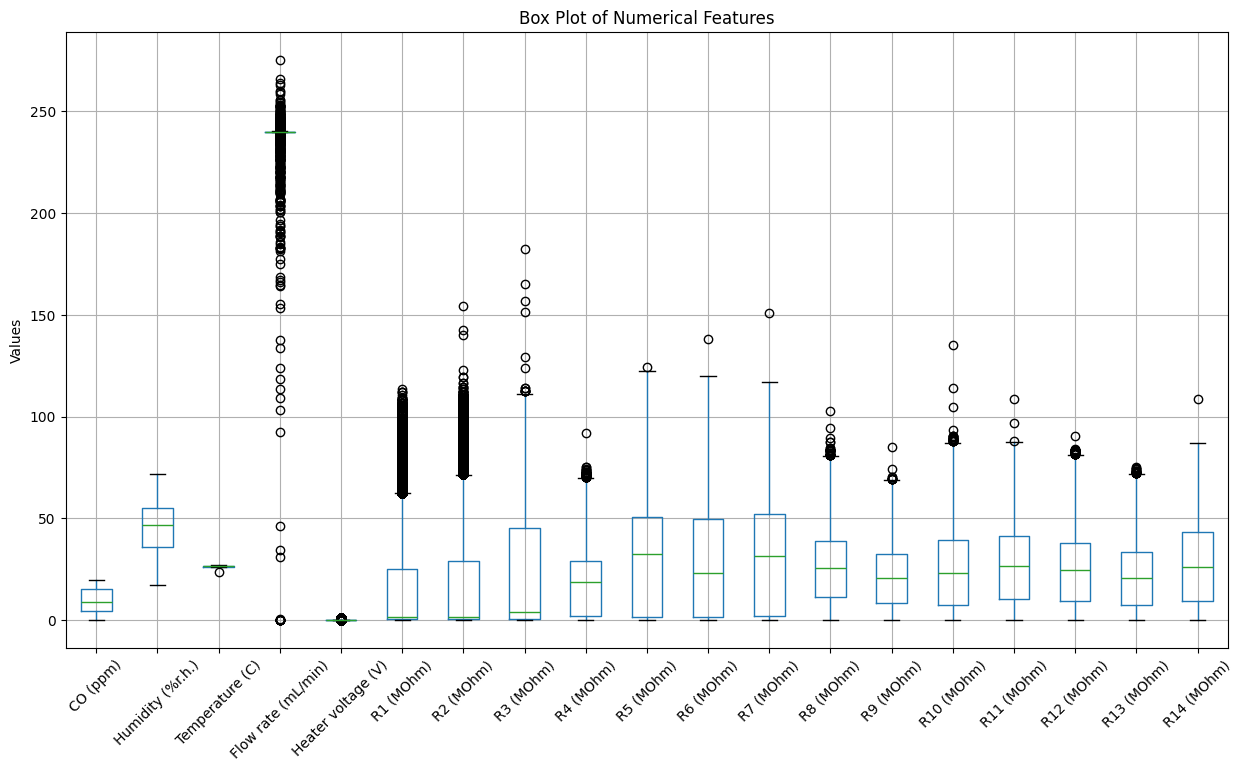

In [7]:
# Create a box plot for all numerical columns in the DataFrame
df.boxplot(figsize=(15, 8), rot=45)
plt.title("Box Plot of Numerical Features")
plt.ylabel("Values")
plt.show()

In [8]:
# Calcular el número de outliers para cada columna numérica
outliers_percentage = {}
for column in df.select_dtypes(include=[np.number]).columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_percentage[column] = f'{round(((df[column] < lower_bound) | (df[column] > upper_bound)).sum()/len(df) * 100, 4)} %'

# Mostrar el número de outliers por columna
outliers_percentage

{'CO (ppm)': '0.0 %',
 'Humidity (%r.h.)': '0.0 %',
 'Temperature (C)': '0.0003 %',
 'Flow rate (mL/min)': '4.0011 %',
 'Heater voltage (V)': '22.4551 %',
 'R1 (MOhm)': '6.2823 %',
 'R2 (MOhm)': '7.4693 %',
 'R3 (MOhm)': '0.0047 %',
 'R4 (MOhm)': '0.026 %',
 'R5 (MOhm)': '0.0003 %',
 'R6 (MOhm)': '0.0003 %',
 'R7 (MOhm)': '0.0003 %',
 'R8 (MOhm)': '0.0105 %',
 'R9 (MOhm)': '0.0037 %',
 'R10 (MOhm)': '0.0085 %',
 'R11 (MOhm)': '0.001 %',
 'R12 (MOhm)': '0.0132 %',
 'R13 (MOhm)': '0.0085 %',
 'R14 (MOhm)': '0.0003 %'}

In [9]:
df['y'] = df['Humidity (%r.h.)']
df.drop(columns=['Humidity (%r.h.)'], inplace=True)

In [10]:
df.to_parquet(os.path.join(DATA_PATH, 'gas_sensor_array_temperature_modulation', 'clean.parquet'))